# 1. The two formulations

The same geodesic can be integrated in two sets of variables (see [the theory](../docs/theory/formulations.md)):

- **(a)** the geodesic equation in $(x^\mu, u^\mu)$, with Christoffel symbols;
- **(b)** Hamilton's equations for $H = \tfrac12 g^{\mu\nu}p_\mu p_\nu$ in $(x^\mu, p_\mu)$.

This notebook builds both for Schwarzschild ($M = 1$), starts them from the same physical point and checks that they trace the same orbit, and which invariants each conserves.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from geoint.plotting import style

style.apply()
%matplotlib inline

In [2]:
from geoint.formulations import Hamiltonian, SecondOrder
from geoint.integrators import get
from geoint.metrics import Schwarzschild
from geoint.testcases.schwarzschild import Eccentric

metric = Schwarzschild()
a, b = SecondOrder(metric), Hamiltonian(metric)
case = Eccentric(20.0, 0.5, n_orbits=3.0)  # (p, e) = (20, 0.5), started at periapsis
x0, p0 = case.initial_xp(metric)
print("x0 =", x0)
print("p0 =", p0)
print("u0 =", metric.g_inv(x0) @ p0)

x0 = [ 0.         13.33333333  1.57079633  0.        ]
p0 = [-0.98192622  0.          0.          4.88677777]
u0 = [1.15520732 0.         0.         0.02748812]


Both states start on the mass shell, $H = -\tfrac12$, to rounding:

In [3]:
for form in (a, b):
    y0 = form.from_xp(x0, p0)
    print(form.name, "relative constraint:", form.relative_constraint(y0, 1))

second_order relative constraint: 0.0


hamiltonian relative constraint: 0.0


Integrate three radial periods with DOP853 at a tight tolerance in both formulations and compare the orbits.

second_order error in phi after 3 periods: 4.97685448408447e-10
hamiltonian error in phi after 3 periods: 3.206395149391028e-10


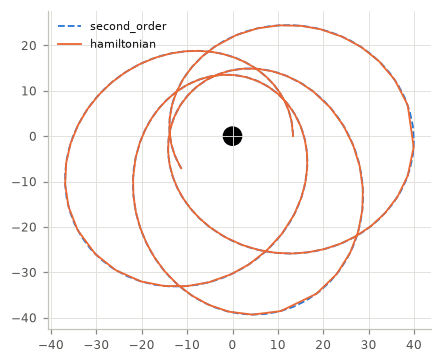

In [4]:
sols = {
    form.name: get("DOP853").solve(case.problem(form), rtol=1e-12, atol=1e-12) for form in (a, b)
}

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for form in (a, b):
    sol = sols[form.name]
    r, phi = sol.y[:, 1], sol.y[:, 3]
    ax.plot(
        r * np.cos(phi), r * np.sin(phi), label=form.name, lw=1.2, ls="--" if form is a else "-"
    )
    print(form.name, "error in phi after 3 periods:", case.errors(sol, form)["error"])
ax.add_patch(plt.Circle((0, 0), 2, color="k"))
ax.set_aspect("equal")
ax.legend();

## Invariants

In (b), $t$ and $\phi$ are cyclic: $\dot p_t$ and $\dot p_\phi$ are the floating-point number zero, so every Runge–Kutta method keeps $E = -p_t$ and $L_z = p_\phi$ **bit for bit**. In (a), $E = f u^t$ and $L_z = r^2\sin^2\theta\,u^\phi$ are nonlinear in the state and drift at the level of the tolerance.

In [5]:
for form in (a, b):
    sol = sols[form.name]
    inv = form.invariants(sol.y)
    dE = np.max(np.abs(inv["E"] / inv["E"][0] - 1))
    dL = np.max(np.abs(inv["Lz"] / inv["Lz"][0] - 1))
    dH = np.max(form.relative_constraint(sol.y, 1))
    print(f"{form.name:>14}: max dE = {dE:.1e}, max dLz = {dL:.1e}, max dH = {dH:.1e}")

  second_order: max dE = 1.0e-13, max dLz = 9.2e-13, max dH = 2.0e-13
   hamiltonian: max dE = 0.0e+00, max dLz = 0.0e+00, max dH = 4.4e-13
